# Battery Degradation Model

As a battery cycles repeatedly, two things happen:
- **Capacity fades** — stores less energy over time
- **Internal resistance increases** — generates more heat per amp

Modelling both using simple linear equations, then linking resistance into the thermal model from notebook 03.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

## Load Cycle Files

In [2]:
# grab all the processed CSVs
cycle_files = glob.glob("../data/processed/B0005_cycle_*.csv")

# pull the number out of each filename (e.g. B0005_cycle_42.csv -> 42)
cycle_nums = sorted([int(f.split("_")[-1].split(".")[0]) for f in cycle_files])

print("First few:", cycle_nums[:5])
print("Last few :", cycle_nums[-5:])
print("Total    :", len(cycle_nums))

First few: [2, 4, 6, 8, 10]
Last few : [600, 604, 608, 612, 614]
Total    : 168


In [3]:
# want one from start, middle and end to compare fresh vs aged battery
early = cycle_nums[0]
mid   = cycle_nums[len(cycle_nums) // 2]
late  = cycle_nums[-1]

selected_cycles = [early, mid, late]
print("Selected:", selected_cycles)

Selected: [2, 294, 614]


## Degradation Model

Two linear equations — one for capacity, one for resistance:

- `Q(n) = Q0 × (1 − kQ × n)` → capacity drops a bit each cycle
- `R(n) = R0 × (1 + kR × n)` → resistance climbs a bit each cycle

`n` = cycle number, `kQ` = fade rate, `kR` = growth rate

In [4]:
def get_degraded_params(n, Q0=2.0, R0=0.01, kQ=1e-4, kR=5e-4):
    # Q0 = 2.0 Ah is typical for an 18650 cell
    # kQ and kR are rough estimates — would need fitting to real data ideally
    Q = Q0 * (1 - kQ * n)   # capacity shrinks linearly
    R = R0 * (1 + kR * n)   # resistance grows linearly
    return Q, R

## Thermal Model (from notebook 03)

Same function as before — just copying it here so this notebook runs standalone.
The connection to degradation: degraded `R` goes in → more joule heating → higher temps.

In [5]:
def run_thermal_sim(current, time, R=0.01, hA=0.1, mass=0.045, Cp=900, T0=25):
    temps = np.zeros(len(time))
    temps[0] = T0
    dt = np.mean(np.diff(time))

    for i in range(1, len(time)):
        Q_gen  = (current[i] ** 2) * R        # I^2 * R heating
        Q_loss = hA * (temps[i-1] - T0)       # heat escaping to surroundings
        dT = (Q_gen - Q_loss) * dt / (mass * Cp)
        temps[i] = temps[i-1] + dT

    return temps

## Simulate Early, Mid, Late — Compare vs Measured

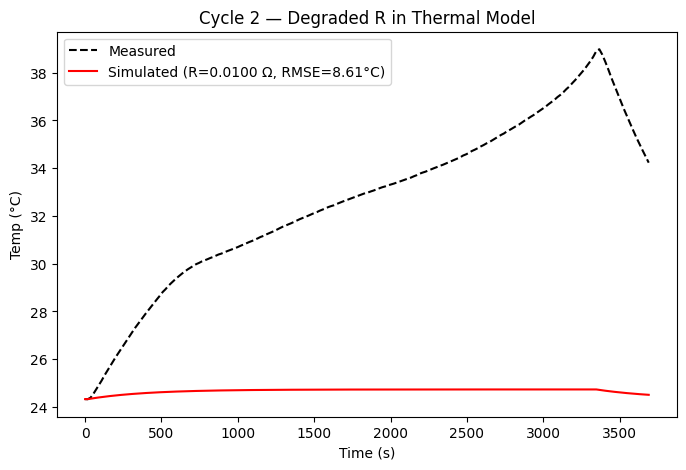

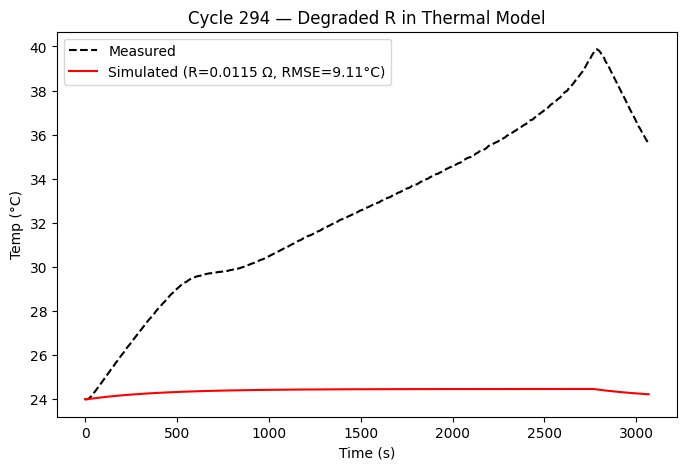

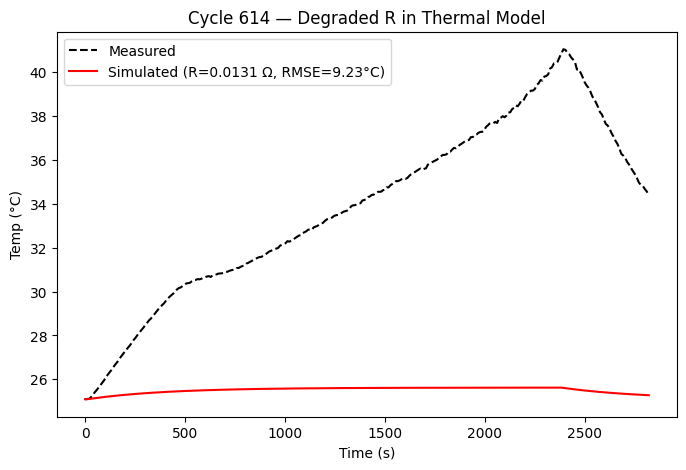

In [6]:
for c in selected_cycles:
    df = pd.read_csv(f"../data/processed/B0005_cycle_{c}.csv")

    t      = df["time_s"].values
    I      = df["current_A"].values
    T_real = df["temp_C"].values
    T0     = T_real[0]  # use first measured value so we start at the right temp

    # get degraded resistance for this cycle number
    cap, R_deg = get_degraded_params(c)

    # thermal sim now uses R_deg instead of a fixed value
    T_sim = run_thermal_sim(I, t, R=R_deg, T0=T0)

    err = np.sqrt(mean_squared_error(T_real, T_sim))

    plt.figure(figsize=(8, 5))
    plt.plot(t, T_real, 'k--', label="Measured")
    plt.plot(t, T_sim,  'r-',  label=f"Simulated (R={R_deg:.4f} Ω, RMSE={err:.2f}°C)")
    plt.xlabel("Time (s)")
    plt.ylabel("Temp (°C)")
    plt.title(f"Cycle {c} — Degraded R in Thermal Model")
    plt.legend()
    plt.show()

## Capacity Fade + Resistance Growth Across All Cycles

Run the degradation model over all cycles and plot both trends.
Using a dual y-axis since the two quantities are on different scales.

In [7]:
# parameters — rough starting values, could be fitted later
Q0 = 2.0
R0 = 0.01
kQ = 1e-4
kR = 5e-4

records = []
for c in cycle_nums:
    Q, R = get_degraded_params(c, Q0=Q0, R0=R0, kQ=kQ, kR=kR)
    records.append({"cycle": c, "capacity_Ah": Q, "resistance_Ohm": R})

df_deg = pd.DataFrame(records)

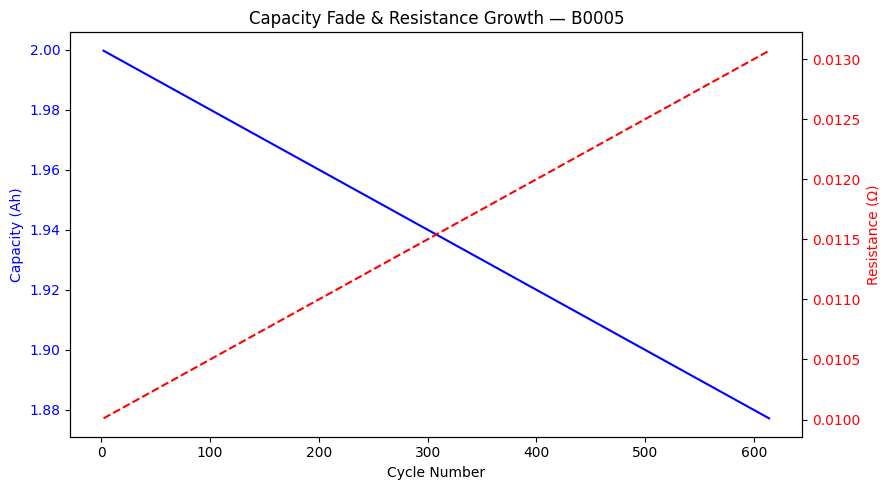

In [8]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# left axis — capacity (blue, going down)
ax1.plot(df_deg["cycle"], df_deg["capacity_Ah"], 'b-', label="Capacity (Ah)")
ax1.set_xlabel("Cycle Number")
ax1.set_ylabel("Capacity (Ah)", color="b")
ax1.tick_params(axis='y', labelcolor="b")

# right axis — resistance (red, going up)
ax2 = ax1.twinx()  # shares x-axis with ax1
ax2.plot(df_deg["cycle"], df_deg["resistance_Ohm"], 'r--', label="Resistance (Ω)")
ax2.set_ylabel("Resistance (Ω)", color="r")
ax2.tick_params(axis='y', labelcolor="r")

plt.title("Capacity Fade & Resistance Growth — B0005")
plt.tight_layout()
plt.show()